In [ ]:
# Name: DVN Surya Kiran
# Roll No: CH.SC.U4CSE24116
# Lab 8 Exercise 2 - SVM Spam Email Classification

In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
data = {
    'WordFrequency': [0.1,0.8,0.2,0.9,0.3,0.7,0.1,0.85,0.15,0.75,
                      0.05,0.95,0.25,0.88,0.12,0.72,0.08,0.82,0.18,0.78],
    'MessageLength': [50,200,60,210,55,195,45,205,65,190,
                      40,220,70,215,48,185,52,208,58,198],
    'Spam':          [0,1,0,1,0,1,0,1,0,1,
                      0,1,0,1,0,1,0,1,0,1]
}
df = pd.DataFrame(data)
print(df)

    WordFrequency  MessageLength  Spam
0            0.10             50     0
1            0.80            200     1
2            0.20             60     0
3            0.90            210     1
4            0.30             55     0
5            0.70            195     1
6            0.10             45     0
7            0.85            205     1
8            0.15             65     0
9            0.75            190     1
10           0.05             40     0
11           0.95            220     1
12           0.25             70     0
13           0.88            215     1
14           0.12             48     0
15           0.72            185     1
16           0.08             52     0
17           0.82            208     1
18           0.18             58     0
19           0.78            198     1


In [ ]:
print(df.isnull().sum())
print(df.shape)

WordFrequency    0
MessageLength    0
Spam             0
dtype: int64
(20, 3)


In [ ]:
x = df[['WordFrequency', 'MessageLength']]
y = df['Spam']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=5)
print(x_train.shape, x_test.shape)

(14, 2) (6, 2)


In [ ]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
model = SVC(kernel='rbf', random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("Predicted:", y_pred)
print("Actual:   ", y_test.values)

Predicted: [0 1 1 1 0 1]
Actual:    [0 1 1 1 0 1]


In [ ]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Accuracy %:", int(metrics.accuracy_score(y_test, y_pred)*100), '%')
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred))

Confusion Matrix:
 [[2 0]
 [0 4]]
Accuracy: 1.0
Accuracy %: 100 %

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



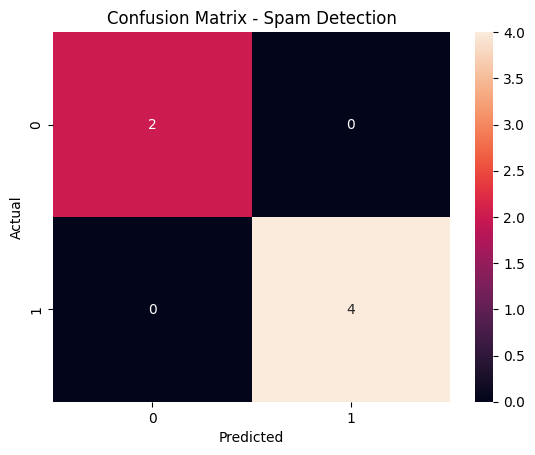

In [ ]:
sn.heatmap(conf_mat, annot=True, fmt='d')
plt.title('Confusion Matrix - Spam Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()